# SFML Project
## Comparing Machine Learning Algorithms for Classification and Regression

**Group members:**  
- MARYAM LACHHAB —  Master of Applied Informatics: Artificial intelligence and Data Science
- EMMA CROISEZ — Master of Physics: Research focus 
- DENIS YUSUFOV — Master of Physics: Research Focus

## 1. Introduction

in this project we ...🚨 TO DO

## 2. Research Questions

The project is organized around the following research questions:

1. How does noise affect classification performance?
2. In the case of SVM, what is the impact of class overlap, class imbalance, and mislabeled data on the number, fraction and location of support vectors?
3. What is the impact of class imbalance on the performance?

These questions are relevant because they help us understand both the predictive power and the limitations of machine learning models under different conditions.

# imports #####################################

In [20]:
# =========================
# Core libraries
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Dataset generators
# =========================
from sklearn.datasets import (
    make_classification,
    make_blobs,
    make_regression
)

# =========================
# Train/test utilities
# =========================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# =========================
# Preprocessing
# =========================
from sklearn.preprocessing import StandardScaler

# =========================
# Models (classification & regression)
# =========================
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor

# =========================
# Metrics (evaluation)
# =========================
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    mean_squared_error,
    r2_score
)

# I Research Question 1

## 1.1 How does noise affect classification performance?

This research question investigates how machine learning classification models behave when the data becomes increasingly noisy and difficult to separate.

The motivation for this experiment comes from previous work with X-ray image datasets used for bone fracture detection. In those datasets, image noise, low quality scans, and limited data often made classification more difficult and negatively affected model performance.

However, instead of working directly with medical images and deep learning models, this project focuses on a simpler and more interpretable experimental setup. The goal is not to reproduce a full medical imaging system, but rather to study the general effect of noisy data on classification algorithms in a controlled environment.

Using a synthetic dataset allows the noise level to be adjusted systematically while keeping the data easy to visualize and analyze. This makes it possible to clearly observe how increasing overlap and dispersion between classes affects classification accuracy and model behavior.


## 1.2 The Dataset

For this experiment, a synthetic classification dataset generated using the `make_blobs()` function from scikit-learn is used.

The dataset contains:
- 500 samples,
- 2 classes,
- and 2 numerical features.

The two classes can be interpreted as simplified representations of:
- fractured bones,
- and non-fractured bones.

Each sample contains two automatically generated numerical features, which represent simplified abstract characteristics used by the classification models.

Only two features are used because this allows the dataset to be visualized directly in two-dimensional space. This makes it easier to observe:
- class separation,
- overlap between classes,
- noise effects,
- and the decision boundaries learned by the machine learning models.

The noise used in this experiment primarily represents class overlap noise rather than label corruption. By increasing the cluster_std parameter, the generated data points become more dispersed, causing the two classes to overlap in the feature space. As overlap increases, the classification task becomes more difficult because samples from different classes appear closer together.
This differs from label noise, where class labels are randomly changed or incorrectly assigned. In this experiment, the labels remain correct, but the spatial separation between the classes becomes less distinct.
The use of make_blobs() is appropriate for this study because it provides a simple and highly visual way to investigate how increasing overlap affects the performance of K-Nearest Neighbors (KNN) and Logistic Regression classifiers.

In [21]:

# synthetic datatset 
##################1️⃣RESEARCH Q11️⃣##########################
from sklearn.datasets import make_blobs
#to test , you can manually change cluster_std values to [1, 3, 5, 7, 9] as examples 
X, y = make_blobs(
        n_samples=500,#500 examples 
        centers=2,#2 classes (broken , not broken bones)
        cluster_std=1,#noise (1 low noise , 9 high noise )
        random_state=42#
    )

## 1.4 Data Preprocessing

Before training the models, we split the datasets into training and test sets. For some algorithms, we also standardize the features because they are sensitive to scale.

In [22]:
##################1️⃣RESEARCH Q11️⃣##########################
# Split the dataset into training and testing data
# 80% of the data will be used to train the models
# 20% will be used to test how well the models perform on unseen data

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Feature values (input data)
    y,                  # Class labels (target values)
    test_size=0.2,      # 20% of the data goes to the test set
    random_state=42     # Ensures reproducible results
)

# Create a StandardScaler object
# Standardization rescales the features so they have:
# mean = 0 and standard deviation = 1

scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# The scaler learns the statistics from the training set only

X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the test data


X_test_scaled = scaler.transform(X_test)

## 1.5 Machine Learning Models

For the classification task, the following machine learning models were used:

- Logistic Regression  
- K-Nearest Neighbors (KNN)  

These models were selected because they represent two different classification approaches:
- a linear probabilistic model (Logistic Regression),
- and a distance-based non-parametric model (KNN).

This allows comparison of how different learning strategies behave as noise increase in the dataset.

---

### Logistic Regression

Logistic Regression is a supervised classification algorithm that predicts the probability that a sample belongs to a particular class. The model attempts to separate classes using a linear decision boundary.

The probability is estimated using the sigmoid function:

$$
P(y=1)=\frac{1}{1+e^{-(w_1x_1+w_2x_2+b)}}
$$

where:
- \(x_1\) and \(x_2\) are input features,
- \(w_1\) and \(w_2\) are learned weights,
- \(b\) is the bias term.

The model learns the parameters that best separate the classes in the training data.

For this experiment, Logistic Regression was used as a baseline classifier because:
- it is simple and interpretable,
- it performs well on linearly separable data,
- and it allows observation of how increasing noise affects a linear model.

Important parameters:
- default Scikit-learn implementation,
- scaled input features using `StandardScaler`.

---

### K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a distance-based supervised learning algorithm. Unlike Logistic Regression, KNN does not learn an explicit mathematical model during training. Instead, classification is based on the labels of nearby samples.

Similarity between samples is commonly measured using Euclidean distance:

$$
d=\sqrt{(x_1-x_2)^2+(y_1-y_2)^2}
$$

The algorithm identifies the \(k\) nearest neighbors and assigns the majority class among them.

For this experiment:
- the number of neighbors was set to \(k = 5\),
- Euclidean distance was used,
- and feature scaling was applied before training.

KNN was selected because it is highly sensitive to local data structure. As noise and overlap increase, neighboring samples from different classes become mixed, making classification more challenging. This makes KNN useful for evaluating how dataset complexity affects model performance.

## 1.6 Methodology of Experiment

The following steps were applied in Research Question 1:

### Step 1: Model Initialization

Two machine learning models were selected for classification:

- Logistic Regression  
- K-Nearest Neighbors (KN"N)



### Step 2: Model Training
Both models were trained using the scaled training dataset:


In [23]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create the Logistic Regression model

log_reg = LogisticRegression()

# Train the model using the training data

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create the 🪩KNN🪩 model

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

# Train the KNN model

knn_model.fit(
    X_train_scaled,
    y_train
)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Step 3: Prediction
After training, both models were used to predict labels on the test dataset:

In [25]:
##################1️⃣RESEARCH Q11️⃣##########################
# Predict class labels using Logistic Regression

log_reg_predictions = log_reg.predict(X_test_scaled)

# Predict class labels using KNN

knn_predictions = knn_model.predict(X_test_scaled)

### Step 4: Evaluation
Model performance was evaluated using accuracy score:

In [26]:
##################1️⃣RESEARCH Q11️⃣##########################
# Calculate Logistic Regression accuracy

log_reg_accuracy = accuracy_score(
    y_test,
    log_reg_predictions
)

# Calculate 🪩kNN🪩 accuracy

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

# Print results

print("Logistic Regression Accuracy:", log_reg_accuracy)
print("KNN Accuracy:", knn_accuracy)

Logistic Regression Accuracy: 1.0
KNN Accuracy: 1.0


## 1.6 Visualisation
In this experiment for the first research question, we used synthetic data generated with the make_blobs function. This creates 2-dimensional data points that belong to two different classes. Because the data is 2D, it can be easily visualized on a scatter plot.
First, we used a scatter plot to show the raw data points. Each point represents an observation, and different colors represent different classes ( broken vs not broken bones). This helps us see how the data is distributed.
Next, we visualized the decision boundary of the machine learning models. The decision boundary shows how the model separates the two classes in the feature space. We used a mesh grid and prediction over the grid points to draw these boundaries.
For Logistic Regression, the decision boundary is mostly linear and smooth.
For K-Nearest Neighbors (KNN), the decision boundary is more flexible and follows the shape of the data more closely.
These visualizations help us understand not only the data itself but also how each model makes decisions.

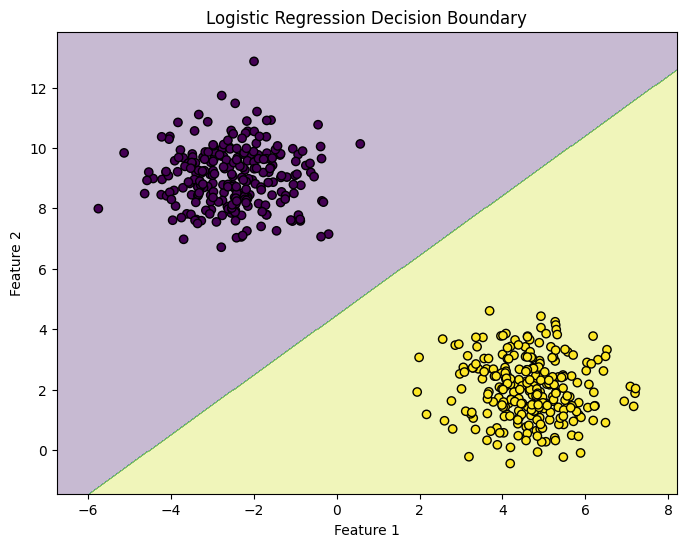

In [27]:
##################1️⃣RESEARCH Q11️⃣##########################
# Create a mesh grid for plotting

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict values across the grid

Z = log_reg.predict(
    scaler.transform(
        np.c_[xx.ravel(), yy.ravel()]
    )
)

# Reshape predictions to match grid

Z = Z.reshape(xx.shape)

# Plot decision boundary

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot original data points

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='k'
)

plt.title("Logistic Regression Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

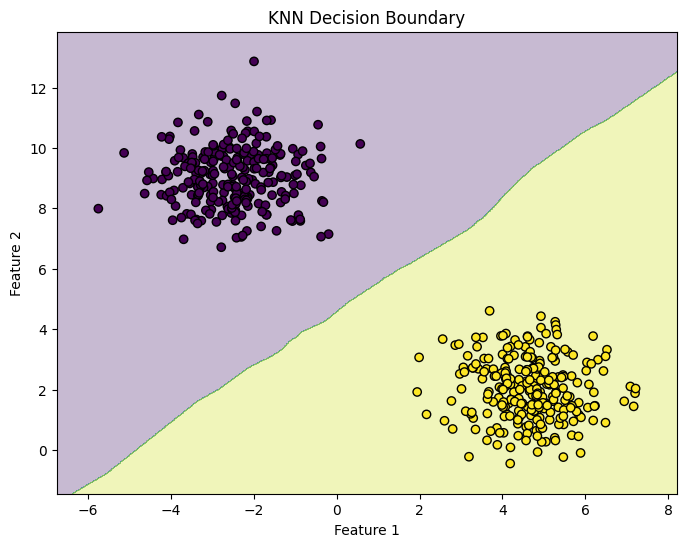

In [28]:
##################1️⃣RESEARCH Q11️⃣##########################
# Predict values across the grid

Z = knn_model.predict(
    scaler.transform(
        np.c_[xx.ravel(), yy.ravel()]
    )
)

# Reshape predictions

Z = Z.reshape(xx.shape)

# Plot decision boundary

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors='k'
)

plt.title("KNN Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## 1.7 Interpretation
From the experiments, we observed how increasing noise affects both models differently.
When the noise level is low, the two classes are clearly separated. In this case:
Logistic Regression performs very well because a clear linear boundary can separate the classes.
KNN also performs well because nearby points mostly belong to the same class.
When the noise level is high, the classes start to overlap. In this case:
Logistic Regression struggles because a single straight line cannot properly separate the mixed data.
KNN is also affected because nearby neighbors may belong to different classes, leading to incorrect voting.
Overall, both models perform better when the data is clean and well-separated. However, Logistic Regression provides a more stable and smooth boundary, while KNN is more flexible but more sensitive to noise.
This shows that data quality (noise level) has a strong impact on model performance and decision boundaries.

# II Research question 2 : 

## 2.1 In the case of SVM, what is the impact of class overlap, class imbalance, and mislabeled data on the number, fraction and location of support vectors?
🚨
For this second research question, we will use a synthetic dataset to show how class overlap, class imbalance and mislabeled data vary the number , fraction and location of support vectors in the case of a soft margin SVM. We will start by introducing the concepts of support vector machine and the need of the soft-margin. Then, we will present the methodology and the code used to create and control the dataset on which we will apply our machine learning algorithm. Finally, we will present our result and discuss them.

## 2.2 Dataset

The experiments use synthetic binary classification datasets generated with
scikit-learn's `make_classification()` function. Synthetic data are used
instead of a real-world dataset because they allow precise control over the
statistical properties of the classification problem.

The goal of the report is to study how a linear soft-margin SVM behaves under
different class overlaps, class imbalances and label noise.

Using artificially generated data makes it possible to vary one factor at a
time while keeping all other characteristics fixed. This produces a controlled
experimental setting and allows clearer interpretation of the observed effects.

Each dataset contains 5000 samples belonging in 2 classes and defined by 3 informative features. The datasets are generated with one cluster per class, adjustable class separation (`class_sep`), adjustable class proportions (`weights`) and adjustable label noise (`flip_y`).

The parameter `class_sep` controls how strongly the two classes overlap. Small values create difficult classification problems with strong overlap and large values produce well-separated classes.

Class imbalance is controlled through the `weights` parameter. For example, (0.50, 0.50) corresponds to balanced classes while (0.95, 0.05) corresponds to severe imbalance.

Label noise is controlled through `flip_y`, which randomly changes a fraction of class labels to simulate mislabeled points.

The experiments are repeated multiple times with different seeds in order to reduce the effect of randomness and obtain stable average results.

In [29]:
##################2️⃣RESEARCH Q22️⃣##########################
#Global settings

# Reproducibility and experimental design
RANDOM_STATE = 42 #seed
TEST_SIZE = 0.30 #30% of the dataset used for testing 
N_REPEATS = 500 #number of time we repeat each experiment

# Baseline/default dataset parameters
BASE_N_SAMPLES = 5000
BASE_CLASS_SEP = 1.5
BASE_CLASS_WEIGHTS = (0.50, 0.50)
BASE_FLIP_Y = 0.00

# Parameters to vary
CLASS_SEPARATIONS = [0.5, 0.8, 1.2, 1.8, 2.5]          # controls overlap
CLASS_WEIGHTS_LIST = [(0.50, 0.50), (0.70, 0.30), (0.85, 0.15), (0.95, 0.05)]  # imbalance
LABEL_NOISE_LIST = [0.00, 0.02, 0.05, 0.10, 0.20]      # mislabeled data

# SVM regularization. We keep it fixed to isolate data effects. In applied work, 
#C should be selected by cross-validation by testing several possible values 
#and choosing the one that gives the best performance on unseen data.
SVM_C = 1.0

### 2.2.1 Data generation function

The function below creates a binary classification dataset with a chosen degree of overlap, imbalance, and label noise. The labels returned by `make_classification` are $0$ and $1$ refering to the $-1$ and $+1$ from the theory above.

In [30]:
##################2️⃣RESEARCH Q22️⃣##########################
#Generate a binary classification dataset with controlled overlap, imbalance, and label noise.

def make_dataset(n_samples, n_features, class_sep, class_weights, flip_y, random_state):

    X, y = make_classification(
        n_samples=n_samples,
        n_features=3,
        n_informative=3,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        n_clusters_per_class=1,
        weights=list(class_weights),
        flip_y=flip_y,
        class_sep=class_sep,
        random_state=random_state
    )

    return np.asarray(X), np.asarray(y)

## 2.3 Data preprocessing 

Before training the SVM, the dataset is divided into a training set (70%) and a test set (30%).

The split is performed using `train_test_split()` with stratification. The latter preserves class proportions in both subsets, which is especially important for the imbalance experiments.

A linear soft-margin Support Vector Machine (SVM) is used throughout the study. The classifier is implemented with scikit-learn's `SVC` using a linear kernel.

Before fitting the SVM, all features are standardized using `StandardScaler()`. Feature standardization transforms every feature so that it has mean = 0, standard deviation = 1. This preprocessing step is important because SVMs rely heavily on Euclidean distances, dot products and geometric margin calculations. Without scaling, variables with larger numerical ranges could dominate the optimization process and distort the separating hyperplane.

The preprocessing and classification steps are combined inside a scikit-learn `Pipeline` for simplicity.

The SVM regularization parameter C is kept fixed at C = 1. This isolates the effects of overlap, imbalance, and label noise without
introducing additional variability from hyperparameter tuning.

For every experiment, the following quantities are measured:
- training error;
- test error;
- balanced test accuracy;
- total number of support vectors;
- support-vector fractions;
- margin width;
- and distance from the support vectors to the decision boundary.

The experiments are repeated 500 times for each setting, and the reported results correspond to mean values and standard deviations across repetitions.

## 2.4 Machine Learning Models
###  Soft-margin Support Vector Machine (SVM) description

### 2.4.1 Training set and notation

Let

$$
\mathcal{D}=\{(\mathbf{x}_n,y_n)\}_{n=1}^{N}
$$

be a binary classification training set, where:

- $N$ is the number of training examples.
- $\mathbf{x}_n \in \mathbb{R}^{d}$ is the feature vector of example $n$.
- $d$ is the number of real-valued input features.
- $y_n \in \{-1,+1\}$ is the class label of example $n$.

The goal is to learn a classification rule that predicts whether a new point $\mathbf{x}$ belongs to class $+1$ or class $-1$.

### 2.4.2 Linear classifier and decision boundary

A linear SVM searches for a classifier of the form

$$
g(\mathbf{x}) = \operatorname{sign}(\mathbf{w}^{T}\mathbf{x}+b),
$$

where $\mathbf{w}\in\mathbb{R}^{d}$ is the weight vector, $b\in\mathbb{R}$ is the bias or intercept term, $\mathbf{w}^{T}\mathbf{x}$ is the dot product, and $\operatorname{sign}(z)$ returns $+1$ if $z\ge 0$ and $-1$ otherwise.

The set of points satisfying

$$
\mathbf{w}^{T}\mathbf{x}+b=0
$$

is a hyperplane. This hyperplane is the decision boundary. The vector $\mathbf{w}$ is orthogonal to the decision boundary, and $b$ shifts the hyperplane away from the origin.

### 2.4.3 Functional margin and geometric margin

For a training example $(\mathbf{x}_n,y_n)$, define the score

$$
f(\mathbf{x}_n)=\mathbf{w}^{T}\mathbf{x}_n+b.
$$

The prediction is correct when $y_n f(\mathbf{x}_n)>0$. The quantity

$$
y_n(\mathbf{w}^{T}\mathbf{x}_n+b)
$$

is called the functional margin. It is positive if the example is correctly classified and negative if the example is misclassified.

The distance from $\mathbf{x}_n$ to the hyperplane is

$$
\frac{|\mathbf{w}^{T}\mathbf{x}_n+b|}{\|\mathbf{w}\|},
$$

where $\|\mathbf{w}\|=\sqrt{w_1^2+\cdots+w_d^2}$ is the Euclidean norm. The signed geometric margin is

$$
\frac{y_n(\mathbf{w}^{T}\mathbf{x}_n+b)}{\|\mathbf{w}\|}.
$$

### 2.4.4 Hard-margin SVM

If the training set is linearly separable, there exists a hyperplane that classifies every training example correctly. The hard-margin SVM chooses the separating hyperplane with the largest margin.

The hard-margin constraints are

$$
y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1, \qquad n=1,\ldots,N.
$$

The margin width is $2/\|\mathbf{w}\|$. Thus, maximizing the margin is equivalent to minimizing $\|\mathbf{w}\|^2$:

$$
\begin{aligned}
\min_{\mathbf{w},b} \quad & ||\mathbf{w}\|^2 \\
\text{subject to} \quad & y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1, \qquad n=1,\ldots,N.
\end{aligned}
$$

### 2.4.5 Why soft margin is needed

In many real data sets, the training examples are not perfectly linearly separable. This can happen because of noise, overlapping classes, outliers, or insufficient features.

The soft-margin SVM allows some examples to violate the hard-margin constraints. It still tries to find a large-margin hyperplane, but it also penalizes violations of the margin.

### 2.4.6 Slack variables

Soft-margin SVM introduces a slack variable $\xi_n$ for each training example.

The soft-margin constraints are

$$
y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1-\xi_n, \qquad n=1,\ldots,N,
$$

with

$$
\xi_n\ge 0, \qquad n=1,\ldots,N.
$$

The slack variable $\xi_n$ measures how much example $n$ violates the margin constraint:

- $\xi_n=0$: the point is correctly classified and lies on or outside the margin.
- $0<\xi_n<1$: the point is correctly classified but lies inside the margin.
- $\xi_n=1$: the point lies exactly on the decision boundary.
- $\xi_n>1$: the point is misclassified.

### 2.4.7 Optimization problem

The soft-margin SVM solves

$$
\begin{aligned}
\min_{\mathbf{w},b,\boldsymbol{\xi}} \quad
& \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{n=1}^{N}\xi_n \\
\text{subject to} \quad
& y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\ge 1-\xi_n, \qquad n=1,\ldots,N, \\
& \xi_n\ge 0, \qquad n=1,\ldots,N.
\end{aligned}
$$

Here $\boldsymbol{\xi}=(\xi_1,\ldots,\xi_N)$ is the vector of slack variables and $C>0$ is a regularization parameter chosen by the user. The term $\frac{1}{2}\|\mathbf{w}\|^2$ encourages a large margin. The term $\sum_{n=1}^{N}\xi_n$ penalizes margin violations.

Large $C$ makes violations expensive, so the algorithm tries harder to classify training points correctly. Small $C$ makes violations less expensive, allowing a wider margin and possibly more training errors. In practice, $C$ is selected using a validation set or cross-validation.

### 2.4.8 Support vectors

A support vector is a training point that directly influences the final decision boundary. It satisfies the following equation :

$$
y_n(\mathbf{w}^{T}\mathbf{x}_n+b)\le 1.
$$

Geometrically, support vectors lie on the margin, inside the margin, or on the wrong side of the decision boundary. Points far outside the margin do not affect the final hyperplane once the solution is found.

## 2.5 Methodology

The experiments vary one factor at a time while holding the other factors fixed:

1. **Class overlap** is controlled by `class_sep` in `sklearn.datasets.make_classification`. A smaller value means the class centers are closer and the classes overlap more.
2. **Class imbalance** is controlled by the class weights. For example, `(0.95, 0.05)` means approximately 95% of observations belong to one class and 5% to the other.
3. **Mislabeled data** is controlled by `flip_y`, the fraction of labels randomly flipped.


For each setting, the experiment is repeated over several random seeds. We report means and standard deviations of training error, test error, balanced test accuracy, total support vectors, support-vector fraction, class-specific support-vector counts, class-specific support-vector rates, and margin width.

The balanced test accuracy gives equal importance to each class, this quantity is crucial when looking at a inbalanced dataset. To have a decent balanced test accuracy, an algorithm would have to perform well on the majority dataset as well as on the minority dataset

A linear soft-margin SVM is used throughout. Features are standardized before fitting because SVMs depend on dot products and Euclidean distances which are strongly scale sensitive. Without scaling, variables with larger numerical ranges could dominate the margin.

### 2.5.1 Model definition

The model is a pipeline containing two operations: standardization of each feature to mean zero and variance one, followed by fitting a linear soft-margin SVM. The linear kernel is chosen because the purpose of the report is to study the geometry of margins and support vectors in an interpretable setting.

In [31]:
##################2️⃣RESEARCH Q22️⃣##########################
#Build the model, soft-margin linear SVM with scaling
def build_linear_svm(C=1.0):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=C))
    ])


#misclassification rate = 1 - accuracy
def classification_error(y_true, y_pred):
    return 1.0 - accuracy_score(np.asarray(y_true), np.asarray(y_pred))

### 2.5.2 Fitting one SVM and extracting scientific quantities

For each fitted model, we extract both performance and the studied quantities. The latter are :

- `n_support_total`: total number of support vectors;
- `support_fraction`: fraction of training points that are support vectors;
- `n_support_class_0` and `n_support_class_1`: support vectors by class;
- `support_rate_class_0` and `support_rate_class_1`: fraction of each class that becomes support vectors;
- `margin_width`: $2/\|\mathbf{w}\|$ for a linear SVM in standardized feature space.

In [32]:
##################2️⃣RESEARCH Q22️⃣##########################
def fit_and_extract_metrics(X_train, X_test, y_train, y_test, C=1.0):
    model = build_linear_svm(C=C)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train) #prediction of the model on the training set
    y_test_pred = model.predict(X_test) #prediction of the model on the testing set

    svm = model.named_steps["svm"]
    support_vectors = svm.support_vectors_
    n_support_total = len(svm.support_vectors_)
    support_per_class = svm.n_support_

    class_counts = np.bincount(y_train, minlength=2)
    support_rate_class_0 = support_per_class[0] / class_counts[0]
    support_rate_class_1 = support_per_class[1] / class_counts[1]

    w = svm.coef_.ravel()
    w_norm = np.linalg.norm(w)
    margin_width = np.nan if w_norm == 0 else 2.0 / w_norm

    if w_norm == 0:
        support_distances = np.full(len(support_vectors), np.nan)
    else:
        support_distances = np.abs(svm.decision_function(support_vectors)) / w_norm

    mean_support_distance = np.nanmean(support_distances)

    return {
        "train_error": classification_error(y_train, y_train_pred),
        "test_error": classification_error(y_test, y_test_pred),
        "balanced_test_accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "n_support_total": n_support_total,
        "n_support_class_0": int(support_per_class[0]),
        "n_support_class_1": int(support_per_class[1]),
        "support_rate_class_0": support_rate_class_0,
        "support_rate_class_1": support_rate_class_1,
        "support_fraction": n_support_total / len(X_train),
        "margin_width": margin_width,
        "mean_support_distance": mean_support_distance,
        "class_0_count_train": int(class_counts[0]),
        "class_1_count_train": int(class_counts[1])
    }

### 2.5.3 Repeated experiments

The next functions run the one-factor-at-a-time experiments. A stratified train-test split is used so that the class proportions in the training and test sets remain close to those of the full dataset.

In [33]:
##################2️⃣RESEARCH Q22️⃣##########################
#Run one experiment for one value of one controlled factor.
def run_single_experiment(setting_type, setting_value, seed):
    if setting_type == "overlap":
        class_sep = setting_value
        class_weights = BASE_CLASS_WEIGHTS
        flip_y = BASE_FLIP_Y
        setting_label = f"class_sep={setting_value:.2f}"

    elif setting_type == "imbalance":
        class_sep = BASE_CLASS_SEP
        class_weights = setting_value
        flip_y = BASE_FLIP_Y
        setting_label = f"{int(setting_value[0]*100)}/{int(setting_value[1]*100)}"

    elif setting_type == "label_noise":
        class_sep = BASE_CLASS_SEP
        class_weights = BASE_CLASS_WEIGHTS
        flip_y = setting_value
        setting_label = f"flip_y={setting_value:.2f}"

    else:
        raise ValueError("setting_type must be overlap, imbalance, or label_noise")

    X, y = make_dataset(
        n_samples=BASE_N_SAMPLES,
        n_features=BASE_N_FEATURES,
        class_sep=class_sep,
        class_weights=class_weights,
        flip_y=flip_y,
        random_state=seed
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y, #Preserves class proportions in both sets
        random_state=seed
    )

    metrics = fit_and_extract_metrics(X_train, X_test, y_train, y_test, C=SVM_C)

    row = {
        "setting_type": setting_type,
        "setting_value": setting_value,
        "setting_label": setting_label,
        "seed": seed,
        **metrics, #add all of the metrics values from the function above
    }
    return row

In [34]:
##################2️⃣RESEARCH Q22️⃣##########################
#run all experiments
def run_repeated_experiments():
    rows = []

    for value in CLASS_SEPARATIONS:
        for repeat in range(N_REPEATS):
            rows.append(run_single_experiment("overlap", value, RANDOM_STATE + repeat))

    for value in CLASS_WEIGHTS_LIST:
        for repeat in range(N_REPEATS):
            rows.append(run_single_experiment("imbalance", value, RANDOM_STATE + repeat))

    for value in LABEL_NOISE_LIST:
        for repeat in range(N_REPEATS):
            rows.append(run_single_experiment("label_noise", value, RANDOM_STATE + repeat))

    return pd.DataFrame(rows)

#todo explain 🚨

In [35]:
##################2️⃣RESEARCH Q22️⃣##########################
#compute means and standard deviations over repeated experiments
def summarize_results(df):
    summary = (
        df.groupby(["setting_type", "setting_label"]) #ensure that metrics are average separately for each condition
          .agg(
              mean_train_error=("train_error", "mean"),
              std_train_error=("train_error", "std"),

              mean_test_error=("test_error", "mean"),
              std_test_error=("test_error", "std"),

              mean_balanced_test_accuracy=("balanced_test_accuracy", "mean"),
              std_balanced_test_accuracy=("balanced_test_accuracy", "std"),

              mean_n_support_total=("n_support_total", "mean"),
              std_n_support_total=("n_support_total", "std"),

              mean_support_rate_class_0=("support_rate_class_0", "mean"),
              mean_support_rate_class_1=("support_rate_class_1", "mean"),
              std_support_rate_class_0=("support_rate_class_0", "std"),
              std_support_rate_class_1=("support_rate_class_1", "std"),

              mean_support_fraction=("support_fraction", "mean"),
              std_support_fraction=("support_fraction", "std"),

              mean_margin_width=("margin_width", "mean"),
              std_margin_width=("margin_width", "std"),

              mean_support_distance=("mean_support_distance", "mean"),
              std_support_distance=("mean_support_distance", "std")
          )
        .reset_index() #converts groups indices back into regular columns
    )
    return summary

## 2.6 Numerical results

The following cell runs the full experiment and produces a summary table. The table is the numerical evidence on which the conclusions are based.

In [36]:
results = run_repeated_experiments()
summary = summarize_results(results)
summary.round(4)

NameError: name 'BASE_N_FEATURES' is not defined

## 2.7 Visualization of quantitative trends

The plots below show means over repeated random seeds. Error bars show one empirical standard deviation.

In [ ]:
##################2️⃣RESEARCH Q22️⃣##########################
def plot_metric(summary_df, setting_type, y_mean_col, y_std_col, ylabel, title, second_mean_col=None,
                second_std_col=None, first_label="Class 0", second_label="Class 1"):
    subset = summary_df[summary_df["setting_type"] == setting_type].copy() #keeping only the rows corresponding to the setting type

    #we order the x-axis in logical order to prevent another unfortunate sort
    if setting_type == "overlap":
        order = [f"class_sep={v:.2f}" for v in CLASS_SEPARATIONS]
    elif setting_type == "imbalance":
        order = [f"{int(a*100)}/{int(b*100)}" for a, b in CLASS_WEIGHTS_LIST]
    elif setting_type == "label_noise":
        order = [f"flip_y={v:.2f}" for v in LABEL_NOISE_LIST]

    subset["setting_label"] = pd.Categorical(subset["setting_label"], categories=order, ordered=True) #=>the order is meaningful
    subset = subset.sort_values("setting_label") #ensure the rows follow the intended order

    x = np.arange(len(subset))
    y = np.asarray(subset[y_mean_col])
    yerr = np.asarray(subset[y_std_col])

    #first curve
    plt.figure(figsize=(7, 4))
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4, label=first_label)

    #optional second curve
    if second_mean_col is not None and second_std_col is not None:
        y2 = np.asarray(subset[second_mean_col])
        yerr2 = np.asarray(subset[second_std_col])
        plt.errorbar(x, y2, yerr=yerr2, marker="s", capsize=4, label=second_label)
        plt.legend()

    plt.xticks(x, subset["setting_label"], rotation=30)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### 2.7.1 Effect of class overlap

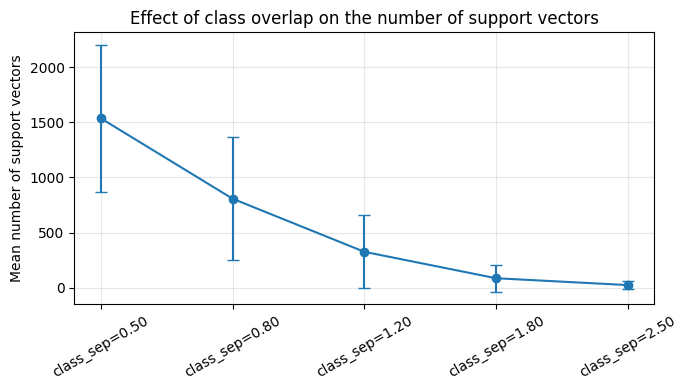

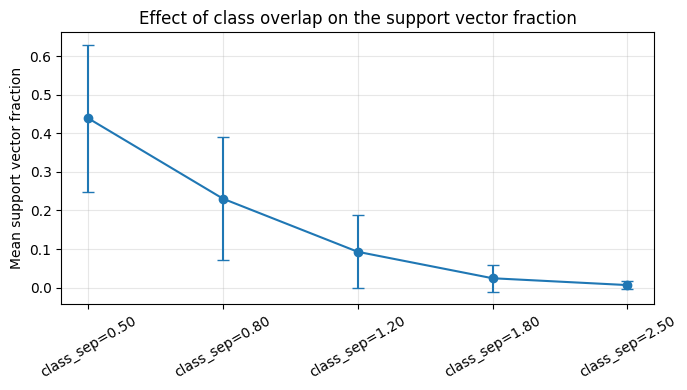

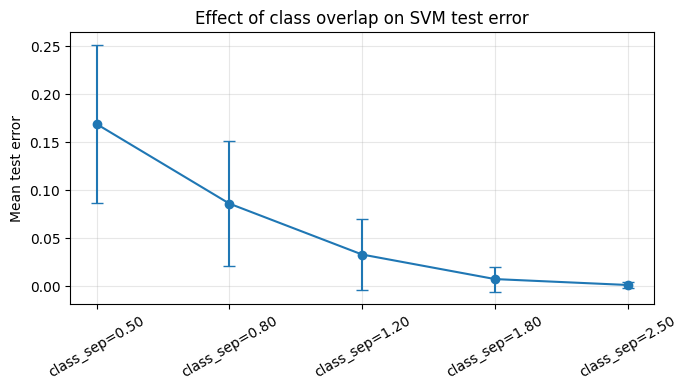

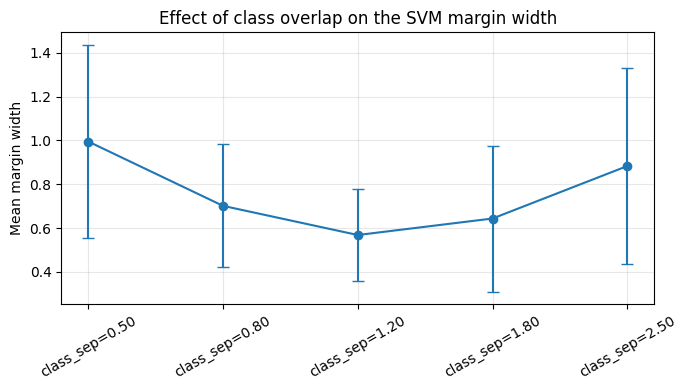

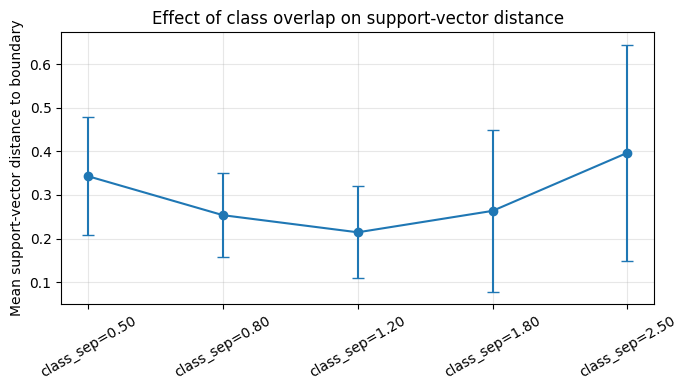

In [ ]:
##################2️⃣RESEARCH Q22️⃣##########################
plot_metric(summary, "overlap", "mean_n_support_total", "std_n_support_total",
            "Mean number of support vectors", "Effect of class overlap on the number of support vectors")
plot_metric(summary, "overlap", "mean_support_fraction", "std_support_fraction",
            "Mean support vector fraction", "Effect of class overlap on the support vector fraction")
plot_metric(summary, "overlap", "mean_test_error", "std_test_error",
            "Mean test error", "Effect of class overlap on SVM test error")
plot_metric(summary, "overlap", "mean_margin_width", "std_margin_width",
            "Mean margin width", "Effect of class overlap on the SVM margin width")
plot_metric(summary, "overlap", "mean_support_distance", "std_support_distance", "Mean support-vector distance to boundary",
            "Effect of class overlap on support-vector distance")

### 2.7.2 Interpretation of overlap plots.

The overlap experiments investigate how the geometric separation between the two classes affects the behaviour of a linear soft-margin SVM. The parameter `class_sep` controls the distance between class distributions. Small values correspond to strong overlap and large values correspond to well-separated classes. The results show a strong and systematic relationship between overlap and all measured SVM quantities.

First, the total number of support vectors decreases sharply as `class_sep` increases. When the classes strongly overlap (`class_sep = 0.50`), many training samples lie close to the separating hyperplane or violate the margin, therfore becoming support vectors. The support-vector fraction exhibits the same trend. Under severe overlap, nearly half of the training samples become support vectors, indicating that the classification problem is geometrically difficult and that the decision boundary depends on a large portion of the training set.

The test error also decreases monotonically as the class separation increases. As the classes become more distinct, the decision boundary becomes easier to estimate and the test error approaches zero.

For moderate overlap levels, the margin width decreases because the classifier attempts to separate increasingly entangled classes, leading to larger weight-vector norms. However, under very strong overlap, the soft-margin SVM increasingly tolerates classification violations instead of fitting highly irregular boundaries. This regularization effect reduces the norm of the separating hyperplane and produces a wider effective margin despite the greater class ambiguity.

In soft-margin SVMs, support vectors are not necessarily located exactly on the canonical margin. Under strong overlap, many support vectors correspond to margin violations or misclassified observations, producing a broader distribution of distances to the separating hyperplane. Consequently, the average support-vector distance does not necessarily decrease monotonically with overlap.

### 2.7.3 Effect of class inbalance

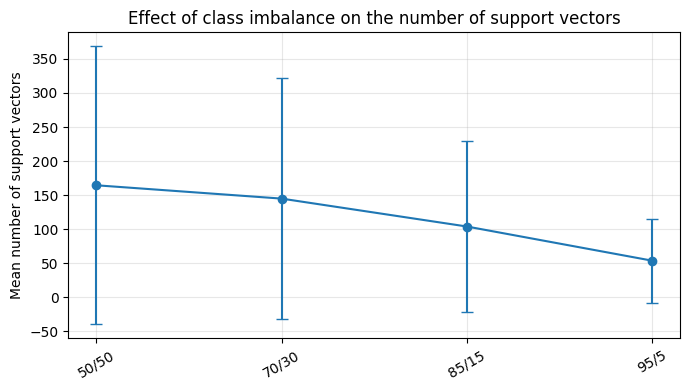

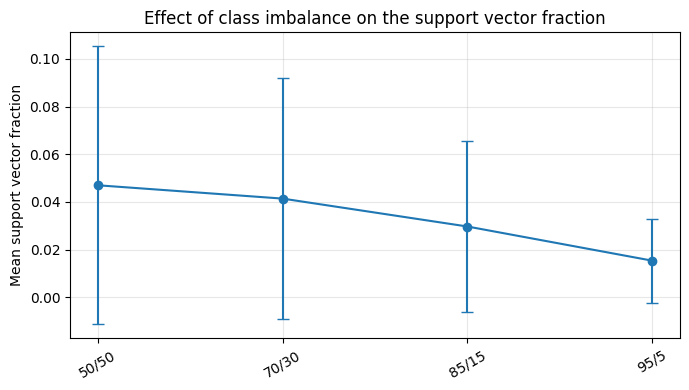

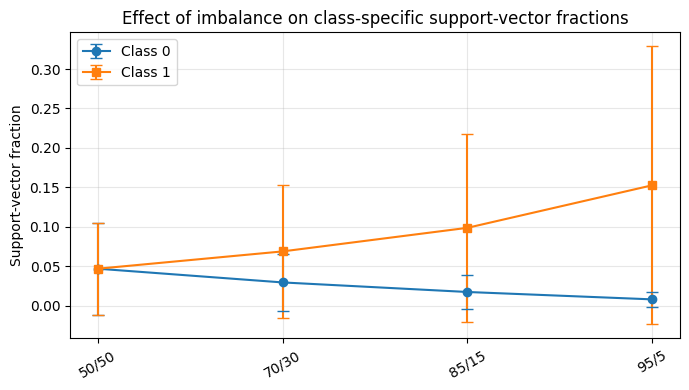

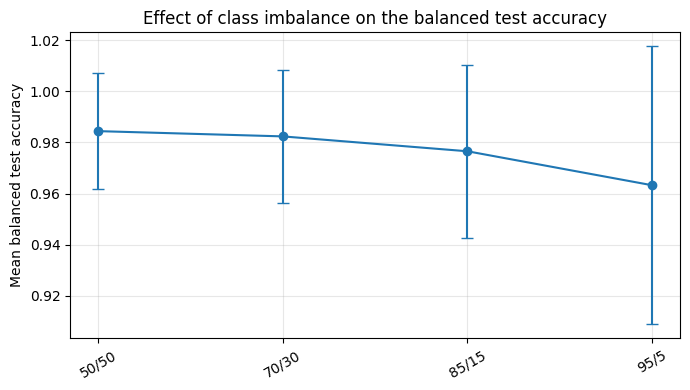

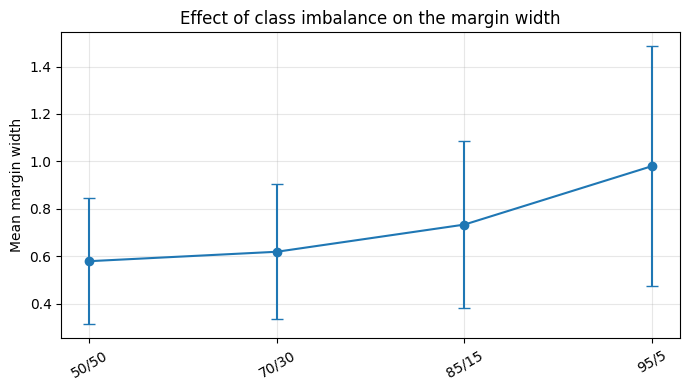

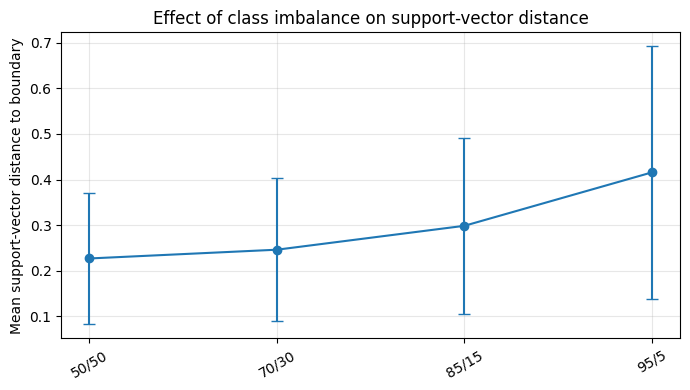

In [ ]:
##################2️⃣RESEARCH Q22️⃣##########################
plot_metric(summary, "imbalance", "mean_n_support_total", "std_n_support_total",
            "Mean number of support vectors", "Effect of class imbalance on the number of support vectors")
plot_metric(summary, "imbalance", "mean_support_fraction", "std_support_fraction",
            "Mean support vector fraction", "Effect of class imbalance on the support vector fraction")
plot_metric(summary, "imbalance", "mean_support_rate_class_0", "std_support_rate_class_0", "Support-vector fraction",
            "Effect of imbalance on class-specific support-vector fractions", second_mean_col="mean_support_rate_class_1",
            second_std_col="std_support_rate_class_1", first_label="Class 0", second_label="Class 1")
plot_metric(summary, "imbalance", "mean_balanced_test_accuracy", "std_balanced_test_accuracy",
            "Mean balanced test accuracy", "Effect of class imbalance on the balanced test accuracy")
plot_metric(summary, "imbalance", "mean_margin_width", "std_margin_width",
            "Mean margin width", "Effect of class imbalance on the margin width")
plot_metric(summary, "imbalance", "mean_support_distance", "std_support_distance", "Mean support-vector distance to boundary",
            "Effect of class imbalance on support-vector distance")

### 2.7.4 Interpretation of imbalance plots

The imbalance experiments examine how unequal class proportions affect the behaviour of a linear soft-margin SVM. Increasing imbalance progressively reduces the size of the minority class while keeping the overlap and label noise fixed.

The total number and fraction of support vectors decrease as imbalance increases. This occurs because the minority class contains fewer observations, so fewer points are available to constrain the separating hyperplane. Consequently, the optimization problem depends on a smaller subset of training samples.

However, the class-specific support-vector fractions reveal an important asymmetry. The support-vector rate of the majority class decreases steadily, whereas the minority-class support-vector rate increases substantially. Under strong imbalance, a large proportion of minority samples become support vectors, indicating that minority observations are critical for determining the decision boundary.

Balanced test accuracy decreases moderately as imbalance increases. Unlike ordinary accuracy, balanced accuracy gives equal importance to both classes and therefore better reflects the degradation in minority-class performance. The results indicate that the classifier becomes progressively biased toward the majority class under severe imbalance.

The margin width and average support-vector distance both increase with imbalance. As the minority class becomes smaller, fewer minority points lie near the separating boundary, allowing the SVM to position a wider margin. The increase in support-vector distance further suggests that the remaining support vectors are less tightly concentrated around the hyperplane.

### 2.7.5 Effect of mislabeled data

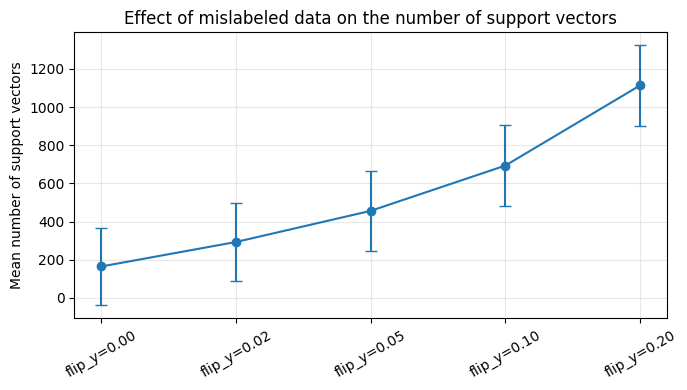

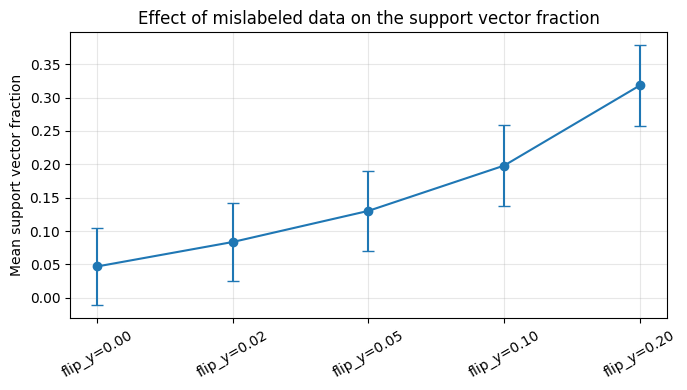

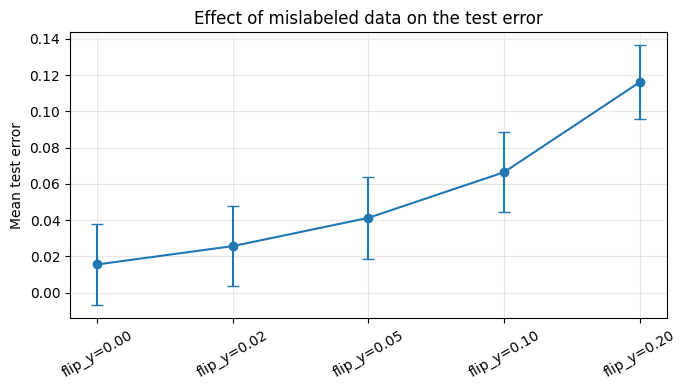

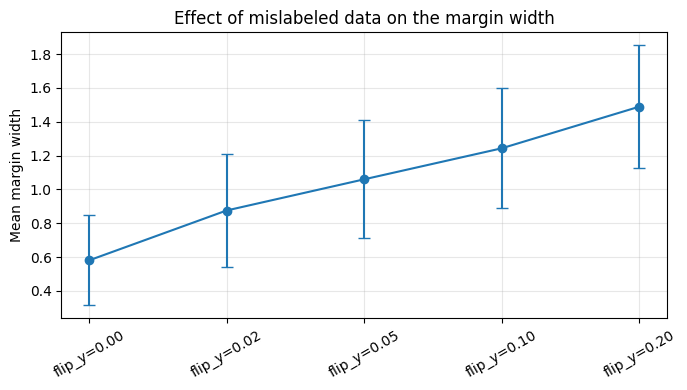

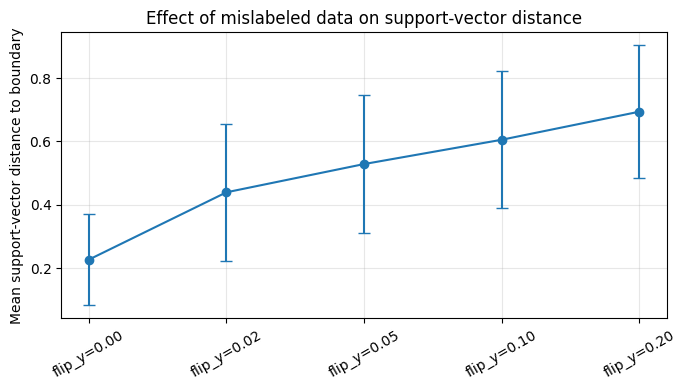

In [ ]:
##################2️⃣RESEARCH Q22️⃣##########################
plot_metric(summary, "label_noise", "mean_n_support_total", "std_n_support_total",
            "Mean number of support vectors", "Effect of mislabeled data on the number of support vectors")
plot_metric(summary, "label_noise", "mean_support_fraction", "std_support_fraction",
            "Mean support vector fraction", "Effect of mislabeled data on the support vector fraction")
plot_metric(summary, "label_noise", "mean_test_error", "std_test_error",
            "Mean test error", "Effect of mislabeled data on the test error")
plot_metric(summary, "label_noise", "mean_margin_width", "std_margin_width",
            "Mean margin width", "Effect of mislabeled data on the margin width")
plot_metric(summary, "label_noise", "mean_support_distance", "std_support_distance", "Mean support-vector distance to boundary",
            "Effect of mislabeled data on support-vector distance")

### 2.7.6 Interpretation of label-noise plots.

The label-noise experiments study the effect of randomly mislabeled training observations on the behaviour of a linear soft-margin SVM. The parameter `flip_y` controls the fraction of labels that are randomly reassigned.

The results show that increasing label noise strongly increases both the total number and fraction of support vectors. Mislabeled observations frequently appear inside the opposite class region or violate the margin constraints, causing many more observations to become support vectors.

The test error increases monotonically with the noise level, reflecting the degradation of the underlying class structure, reducing generalization performance.

Interestingly, both the margin width and the average support-vector distance increase with label noise. In a soft-margin SVM with fixed regularization parameter C, the algorithm increasingly tolerates margin violations rather than fitting highly irregular data points, therefore increasing the geometric margin. 

The increase in support-vector distance further indicates that support vectors become more broadly distributed around the decision boundary under noisy conditions.

## 2.8 Final conclusions :

The experiments confirm the theoretical behaviour of support vectors in linear soft-margin SVMs and show how different forms of data difficulty affect the geometry and performance of the classifier.

1. **Class overlap**
----------------
Increasing overlap makes the classification problem more ambiguous. More observations lie near or inside the margin, which increases the number of support vectors, the support-vector fraction and the test error. At low overlap, the classes become easier to separate and the SVM relies on a much smaller subset of data points.

2. **Class imbalance**
------------------
Class imbalance changes the distribution of support vectors across classes. Although the total number of support vectors decreases, the minority-class support-vector fraction increases substantially. This indicates that minority samples become disproportionately important for determining the separating boundary. Balanced accuracy also decreases under strong imbalance, showing degraded minority-class performance despite relatively high global accuracy.

3. **Label noise**
---------------
Mislabeled observations introduce contradictory constraints into the optimization problem. As label noise increases, support-vector counts increase strongly, as well as support-vector fractions and test error. The classifier becomes geometrically more complex because noisy observations frequently lie inside the margin or on the wrong side of the decision boundary.

# III Research question 3 

## What is the impact of class imbalance on the performance? 

The research question is motivated in the context of binary classfication between signal and background, in which case background is over-dominating the signal. 

For instance, Gamma-ray Cherenkov telescopes data can be classified between the following two classes: gamma-rays (signal) and cosmic ray induced hadronic showers (background). 

Real data from the MAGIC gamma telescope is available on Kaggle. The idea is to use such dataset to potentially compare the performance between imbalanced classes and a balanced version (or something in those lines).





In [ ]:
# code for training the models etc 
df = pd.read_csv('telescope_data.csv')

print(f'Dataset Shape : {df.shape}')
print(f'Target Classes: {df["class"].unique()}')

Dataset Shape : (19020, 12)
Target Classes: ['g' 'h']


# interpretation 

# visualization

In [ ]:
# code for visualization 

# Results and discussion

# Conclusion